# Stark shift

In [1]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [2]:
np.arcsin(0.5)

np.float64(0.5235987755982989)

In [3]:
def Rabi_to_solid_angle(amp):
    theta = np.arcsin(np.round(2*amp, 4))
    SA = np.pi*2*(1-np.cos(theta))
    return SA
def sine_fit_fun(x, a, b, c, d):
    return a*np.sin(2*np.pi*b * x + c) + d 

In [4]:
x = 1; z= 10;
init = qt.basis(2, 0)
H  = x*qt.sigmax() + z*qt.sigmaz()

In [38]:
time = np.linspace(0, 4, 401)
states = []
zexp = []
xexp = []
for t in time:
    state = (-1j * t* np.pi * H).expm() * init
    states.append(state)
    xexp.append(qt.expect(qt.sigmax()/2, state))
    zexp.append(qt.expect(qt.sigmaz()/2, state))

C:\Users\z5459883\AppData\Local\Temp\ipykernel_6464\27482250.py:5: OptimizeWarning: Covariance of the parameters could not be estimated
  sinfit = curve_fit(sine_fit_fun, time, zexp, p0=(0.5, np.sqrt(x**2 + z**2), 0, 0))


np.float64(0.0)

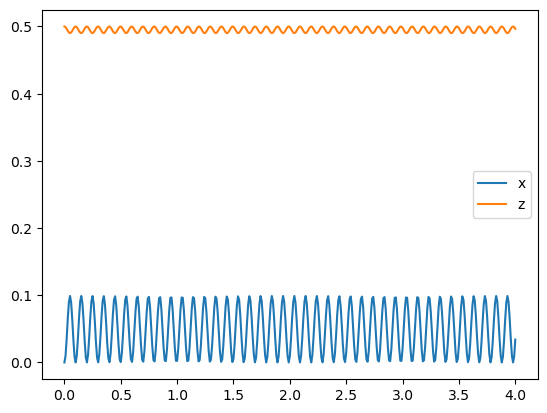

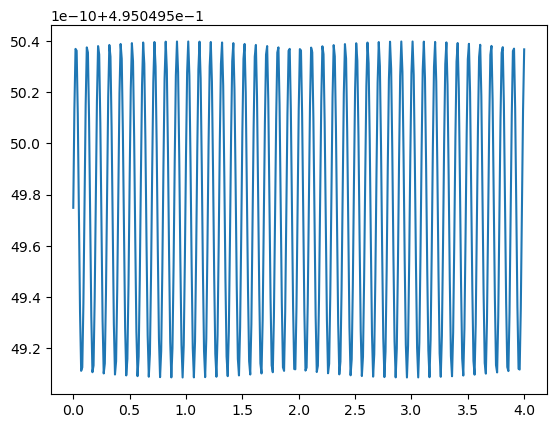

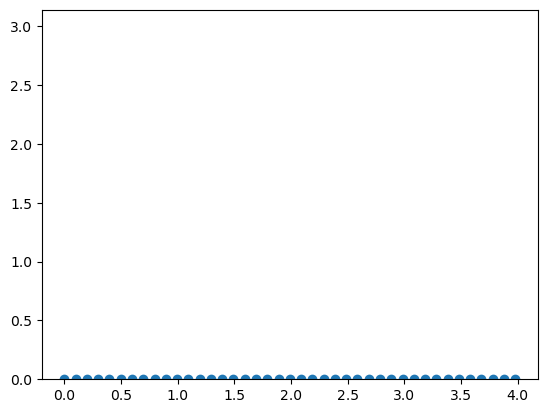

In [39]:
plt.plot(time, xexp, label='x')
plt.plot(time, zexp, label='z')
plt.legend()

sinfit = curve_fit(sine_fit_fun, time, zexp, p0=(0.5, np.sqrt(x**2 + z**2), 0, 0))
f_fit = sinfit[0][1]
amp_fit = sinfit[0][0]

periods = np.arange(0, time[-1], 1/f_fit)
geom_phase = np.mod(np.arange(len(periods))*Rabi_to_solid_angle(amp_fit)/2, 2*np.pi)
plt.figure()
plt.plot(time, sine_fit_fun(time, *sinfit[0]))
plt.figure()
plt.scatter(periods, geom_phase)
plt.ylim(0, np.pi)

Rabi_to_solid_angle(amp_fit)/2

In [7]:
0.00015395752042567773

0.00015395752042567773

In [8]:
amp_fit

np.float64(6.584749412397173e-11)

# actaul single spin ss sims

In [104]:
def Hrf(det, amp):
    return det*qt.sigmaz()/2 + amp*qt.sigmax()/2

def frame_trans(psi, det, t):
    return (1j*np.pi*2*Hrf(det, 0)*t).expm() * psi

In [110]:
detuning = 1
amp = 1
frabi = np.sqrt(detuning**2 + amp**2)/2
angle = np.pi

time = np.linspace(0, angle/(2*np.pi*frabi), 100)

init_state0 = qt.basis(2, 0)
init_state1 = qt.basis(2, 1)
state_RF0 = []
state_RF1 = []
state_LF0 = []
state_LF1 = []
for t in time:
    state_rf0 = (-1j*2*np.pi*Hrf(detuning, amp)*t).expm() * init_state0
    state_rf1 = (-1j*2*np.pi*Hrf(detuning, amp)*t).expm() * init_state1

    state_RF0.append(state_rf0)
    state_LF0.append(frame_trans(state_rf0, detuning, t))
    state_RF1.append(state_rf1)
    state_LF1.append(frame_trans(state_rf1, detuning, t))


In [106]:
%matplotlib inline

In [111]:
state_LF0[-1]

Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[ 6.05699867e-01-7.95693202e-01j]
 [-1.33129358e-16+1.01341113e-16j]]

In [ ]:
state_LF1[-1]

Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[1.31454942e-16+1.00066509e-16j]
 [6.05699867e-01+7.95693202e-01j]]

In [ ]:
qt.ket2dm((state_LF0[-1] + state_LF1[-1])/np.sqrt(2))


Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 0.5       +0.j         -0.13312767-0.48195127j]
 [-0.13312767+0.48195127j  0.5       +0.j        ]]

In [108]:
np.angle(state_LF[-1][0])

array([-0.92015118])

In [109]:
state_RF[-1]

Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[-1.]
 [ 0.]]

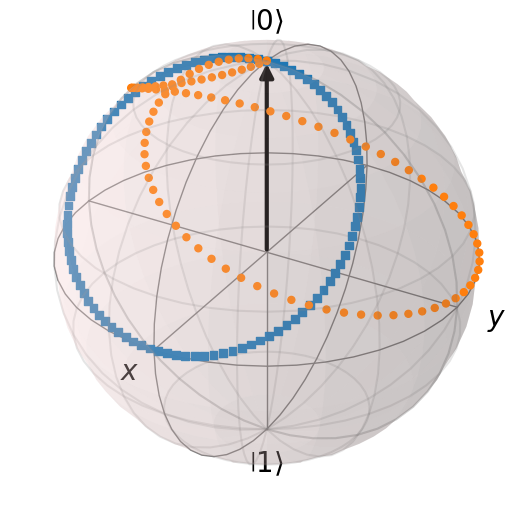

In [100]:
# Extract Bloch coordinates for both trajectories
x_rf = [qt.expect(qt.sigmax(), s) for s in state_RF]
y_rf = [qt.expect(qt.sigmay(), s) for s in state_RF]
z_rf = [qt.expect(qt.sigmaz(), s) for s in state_RF]

x_lf = [qt.expect(qt.sigmax(), s) for s in state_LF]
y_lf = [qt.expect(qt.sigmay(), s) for s in state_LF]
z_lf = [qt.expect(qt.sigmaz(), s) for s in state_LF]

# Single Bloch sphere with both trajectories
b = qt.Bloch()
b.vector_color = ['k']

b.add_points([x_lf, y_lf, z_lf], colors='C1')   # lab frame
b.add_points([x_rf, y_rf, z_rf], colors='C0')   # rotating frame
b.add_states([state_RF[0]])        # initial state marker
# b.add_annotation([0,0,1], ' |0> ')
b.show()
# plt.title("Trajectories: RF (C0) vs LF (C1)")
# plt.show()



In [ ]:

ValueError: 'c' argument has 2 elements, which is inconsistent with 'x' and 'y' with size 100.

ValueError: 'color' kwarg must be a color or sequence of color specs.  For a sequence of values to be color-mapped, use the 'c' argument instead.

# geom phase vs detuning

Text(0.5, 1.0, 'geometric phase vs detuning')

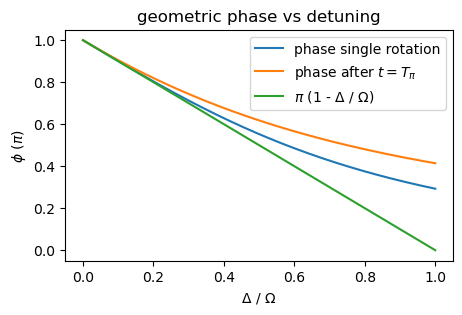

In [9]:
detuning = np.linspace(0.000000000001, 1, 1001)
rabi_F = np.sqrt(1+detuning**2)
geom_phase = np.pi*(1-np.cos(np.pi/2 - np.arctan(detuning)))
plt.figure(figsize= (5, 3))
plt.plot(detuning, geom_phase/np.pi, label='phase single rotation')
plt.plot(detuning, geom_phase*rabi_F/np.pi, label='phase after $t=T_{\pi}$')
plt.plot(detuning, 1 - 1*detuning, label='$\pi$ (1 - $\Delta$ / $\Omega$)')
plt.legend()
plt.xlabel(r'$\Delta \ /  \ \Omega$')
plt.ylabel('$\phi \  (\pi)$')
plt.title('geometric phase vs detuning')

Text(0.5, 1.0, 'geometric phase vs detuning')

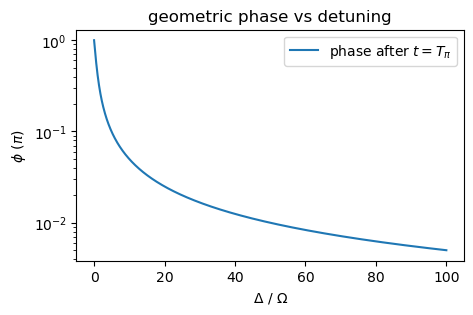

In [16]:
detuning = np.linspace(0.000000000001, 100, 1001)
rabi_F = np.sqrt(1+detuning**2)
geom_phase = np.pi*(1-np.cos(np.pi/2 - np.arctan(detuning)))
plt.figure(figsize= (5, 3))
# plt.semilogy(detuning, geom_phase/np.pi, label='phase single rotation')
plt.semilogy(detuning, geom_phase*rabi_F/np.pi, label='phase after $t=T_{\pi}$')
# plt.plot(detuning, 1 - 1*detuning, label='$\pi$ (1 - $\Delta$ / $\Omega$)')
plt.legend()
plt.xlabel(r'$\Delta \ /  \ \Omega$')
plt.ylabel('$\phi \  (\pi)$')
plt.title('geometric phase vs detuning')

Text(0.5, 1.0, 'geometric phase vs detuning')

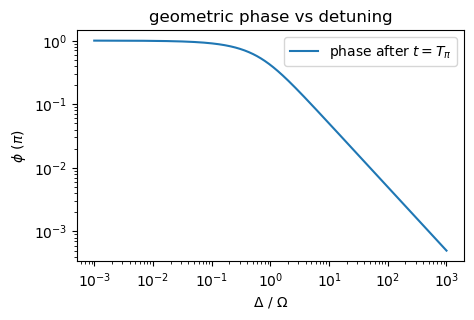

In [24]:
detuning = np.logspace(-3, 3, 1001)
rabi_F = np.sqrt(1+detuning**2)
geom_phase = np.pi*(1-np.cos(np.pi/2 - np.arctan(detuning)))
plt.figure(figsize= (5, 3))
# plt.semilogy(detuning, geom_phase/np.pi, label='phase single rotation')
plt.loglog(detuning, geom_phase*rabi_F/np.pi, label='phase after $t=T_{\pi}$')
# plt.plot(detuning, 1 - 1*detuning, label='$\pi$ (1 - $\Delta$ / $\Omega$)')
plt.legend()
plt.xlabel(r'$\Delta \ /  \ \Omega$')
plt.ylabel('$\phi \  (\pi)$')
plt.title('geometric phase vs detuning')

(0.0, 6.283185307179586)

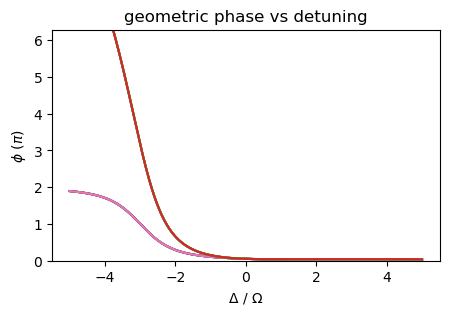

In [37]:
freqs = np.arange(-3, 4)
detuning = np.linspace(-5.001, 5, 1001)
rabi_F = np.sqrt(1+detuning**2)
geom_phases = np.zeros((len(freqs), len(detuning)))
for g in range(len(freqs)):
    for f in range(len(freqs)):
        det = detuning + f
        geom_phases[g] = np.pi*(1-np.cos(np.pi/2 - np.arctan(det-freqs[f])))

plt.figure(figsize= (5, 3))
plt.plot(detuning, geom_phases.T/np.pi, label='phase single rotation')
plt.plot(detuning, (geom_phases*(rabi_F/np.pi)).T, label='phase after $t=T_{\pi}$')
# plt.plot(detuning, 1 - 1*detuning, label='$\pi$ (1 - $\Delta$ / $\Omega$)')
# plt.legend()
plt.xlabel(r'$\Delta \ /  \ \Omega$')
plt.ylabel('$\phi \  (\pi)$')
plt.title('geometric phase vs detuning')
plt.ylim(0, 2*np.pi)

# Errors vs Detuning and Pulse duration

In [53]:
Ndetuning = 101; Ndrivetime = 101
detunings = np.linspace(-0.25, 0.25, Ndetuning)
drive_time = np.linspace(0.9, 1.1, Ndrivetime)

detuning_arr = np.array([detunings]*Ndrivetime)
drivetime_arr = np.array([drive_time]*Ndetuning).T

In [54]:
geom_phase_array = np.pi*(1-np.cos(np.arctan(1/detuning_arr)))*np.sqrt(1+detuning_arr**2)*drivetime_arr
geom_phase_array

C:\Users\z5459883\AppData\Local\Temp\ipykernel_20520\1786170128.py:1: RuntimeWarning: divide by zero encountered in divide
  geom_phase_array = np.pi*(1-np.cos(np.arctan(1/detuning_arr)))*np.sqrt(1+detuning_arr**2)*drivetime_arr


array([[2.20759328, 2.21833399, 2.22913947, ..., 2.22913947, 2.21833399,
        2.20759328],
       [2.21249904, 2.22326362, 2.23409311, ..., 2.23409311, 2.22326362,
        2.21249904],
       [2.21740481, 2.22819325, 2.23904675, ..., 2.23904675, 2.22819325,
        2.21740481],
       ...,
       [2.68835804, 2.70143784, 2.7145965 , ..., 2.7145965 , 2.70143784,
        2.68835804],
       [2.6932638 , 2.70636747, 2.71955015, ..., 2.71955015, 2.70636747,
        2.6932638 ],
       [2.69816956, 2.7112971 , 2.72450379, ..., 2.72450379, 2.7112971 ,
        2.69816956]])

In [55]:
leakage_error = detuning_arr**2*np.sin(np.sqrt(1+detuning_arr**2)*2*np.pi*drivetime_arr)

Text(0, 0.5, 'drive time ($t_{\\pi}$)')

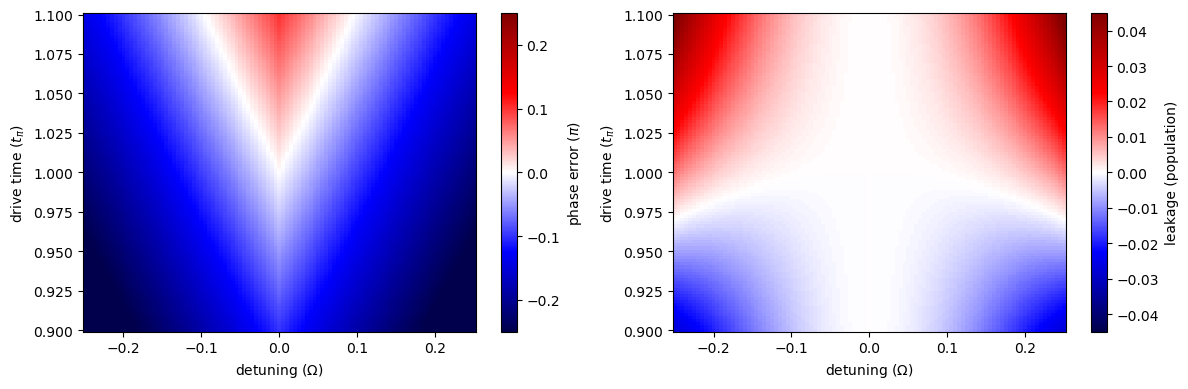

In [83]:
fig, axs = plt.subplots(1, 2, figsize=(12,4), tight_layout=True)
ax = axs[0]
c1 = ax.pcolormesh(detuning_arr, drivetime_arr, geom_phase_array/np.pi - 1, cmap='seismic')
c1.set_clim(-0.25, 0.25)
ax.set_xlabel('detuning ($\Omega$)')
ax.set_ylabel('drive time ($t_{\pi}$)')
fig.colorbar(c1, ax=ax, label='phase error ($\pi$)')
ax = axs[1]
c2 = ax.pcolormesh(detuning_arr, drivetime_arr, leakage_error, cmap='seismic')
c2.set_clim(-0.045, 0.045)
fig.colorbar(c2, ax=ax, label='leakage (population)')
ax.set_xlabel('detuning ($\Omega$)')
ax.set_ylabel('drive time ($t_{\pi}$)')

In [25]:
# multiple transitions